                                ### == D2: Tabular Data Project == ###

Setul de date este compus din informatii despre persoane evaluate pentru autism(ASD).  Acesta contine atat date comportamentale cat si date personale sau informatii legate de membrii ai familiei pacientilor.
Link care sursa(Kaggle):
https://www.kaggle.com/datasets/stealthtechnologies/predict-autism-spectrum-disorder-asd

Proiect realizat de: 
Tura Iulia Adriana - gr.5
Trif Marius Andrei - gr.8

In [115]:
import os
import subprocess

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from math import log2

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC



In [116]:
input_file = "AutismV1.csv"
data = pd.read_csv(input_file, header = 0)

Tratarea valorilor lipsa imputare sau eliminare- justificata

In [117]:
print("Date lipsa:")
data = data.replace('?', pd.NA)
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])


Date lipsa:
age           2
ethnicity    95
relation     95
dtype: int64


Pentru coloana age, care este o variabila numerica continua, am inlocuit valorile lipsa cu mediana celorlalte valori. Am ales aceasta metoda deoarece numarul valorilor lipsa este foarte redus, astfel incat utilizarea medianei nu afecteaza semnificativ distributia datelor.

In [121]:
#errors='coerce' inlocuieste automat semnul intrebarii cu NaN in caz ca nu exista
data['age'] = pd.to_numeric(data['age'], errors='coerce')
data['age'] = data['age'].fillna(data['age'].median())
data['age'][62:65]
#La pozitia 62 s-a inlocuit cu valoarea mediana a coloanei

62    29.698006
63    19.000000
64    29.000000
Name: age, dtype: float64

Pentru coloanele ethnicity si relation, unde nu avem valori numerice si nu putem calcula media, am ales o alta abordare. Numarul de valori lipsa e destul de ridicat deci nu putem ignora aceste linii pe viitor, ignorarea lor ducand la pierderea unei cantitati semnificative de date, deci vom inlocui valorile lipsa cu valorile cel mai frecvent intalnite.

In [122]:
maxFrequency = data['ethnicity'].value_counts().idxmax()
data['ethnicity'] = data['ethnicity'].fillna(maxFrequency)
data['ethnicity'][13:16]
#La linia 14 s-a inlocuit cu valoarea cea mai frecventa a coloanei

13       White-European
14       White-European
15    'Middle Eastern '
Name: ethnicity, dtype: str

In [123]:
maxFrequency = data['relation'].value_counts().idxmax()
data['relation'] = data['relation'].fillna(maxFrequency)
data['relation'][11:16]
#La linia 14 s-a inlocuit cu valoarea cea mai frecventa a coloanei

11    Parent
12      Self
13      Self
14      Self
15    Parent
Name: relation, dtype: str

Am eliminat outlierii din coloana age folosind metoda z-score, pastrand doar valorile care au un z-score mai mic de 2.5

In [124]:
cols_outliers = ['age']

z_scores = np.abs((data[cols_outliers] - data[cols_outliers].mean()) / data[cols_outliers].std())
outliers = (z_scores < 2.5).all(axis=1)
data = data[outliers].reset_index(drop=True)

Encoding variabile categorice: OneHotEncoder. Am ales aceasta metoda pentru a trata variabilele categorice deoarece ne construieste coloane binare separate si egale ca importanta, in care avem doar valori de 0 si 1 prin care ne semnifica prezenta sau absenta acelei valori in datele noastre. Prima coloana construita v-a fi eliminata din contstructia finala deoarece se poate deduce prezenta ei prin negarea celorlalte valori. Daca ne uitam la cealalta posibilitate LabelEncoder, aceasta ne transforma fiecare element diferit din coloana noastra intr-un numar, astfel algoritmul crede ca un element este mai important fata de celalalt, acest lucru fiind gresit. 

In [125]:
if 'age_desc' in data.columns:
    data = data.drop(columns=['age_desc'])

data["gender"] = data["gender"].map({"m": 1, "f": 0})
data["jaundice"] = data["jaundice"].map({"yes": 1, "no": 0})
data["pdd_austim"] = data["pdd_austim"].map({"yes": 1, "no": 0})
data["used_app_before"] = data["used_app_before"].map({"yes": 1, "no": 0})

data['Class/ASD'] = data['Class/ASD'].map({'YES': 1, 'NO': 0})

data.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,pdd_austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26.0,0,White-European,0,0,'United States',0,6,Self,0
1,1,1,0,1,0,0,0,1,0,1,24.0,1,Latino,0,1,Brazil,0,5,Self,0
2,1,1,0,1,1,0,1,1,1,1,27.0,1,Latino,1,1,Spain,0,8,Parent,1
3,1,1,0,1,0,0,1,1,0,1,35.0,0,White-European,0,1,'United States',0,6,Self,0
4,1,0,0,0,0,0,0,1,0,0,40.0,0,White-European,0,0,Egypt,0,2,Self,0


In [126]:
data = pd.get_dummies(data, columns=['ethnicity', 'contry_of_res', 'relation'], drop_first=True)
data.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,contry_of_res_Spain,contry_of_res_Sweden,contry_of_res_Tonga,contry_of_res_Turkey,contry_of_res_Ukraine,contry_of_res_Uruguay,relation_Others,relation_Parent,relation_Relative,relation_Self
0,1,1,1,1,0,0,1,1,0,0,...,False,False,False,False,False,False,False,False,False,True
1,1,1,0,1,0,0,0,1,0,1,...,False,False,False,False,False,False,False,False,False,True
2,1,1,0,1,1,0,1,1,1,1,...,True,False,False,False,False,False,False,True,False,False
3,1,1,0,1,0,0,1,1,0,1,...,False,False,False,False,False,False,False,False,False,True
4,1,0,0,0,0,0,0,1,0,0,...,False,False,False,False,False,False,False,False,False,True


Normalizare/standardizare (StandardScaler, MinMaxScaler). Varianta aleasa pentru aceasta reprezentare este MinMaxScaler deoarece ia cea mai mica valoare din coloana noastra si o aduce la 0, si pe cea mai mare o aduce la 1. Restul numerelor sunt puse in acest interval. Am ales aceasta metoda deoarece in tabelul nostru avem valori predominante de 0 si 1 in majoritatea coloanelor. Totodata StandardScaler, calculeaza valoarea medie a unei coloane si pe aceea o aduce in 0, avand posibilitatea de a exista atat valori pozitive cat si valori negative. Ingreunandu-ne toata situatia de calcul si de afisare citire date.

In [127]:
data['age'] = pd.to_numeric(data['age'], errors='coerce')
coloane_de_normalizat = ['age', 'result']
scaler = MinMaxScaler()
data[coloane_de_normalizat] = scaler.fit_transform(data[coloane_de_normalizat])
print("Varsta:")
print(data['age'][0:5])
print("Rezultat:")
print(data['result'][0:5])

Varsta:
0    0.191489
1    0.148936
2    0.212766
3    0.382979
4    0.489362
Name: age, dtype: float64
Rezultat:
0    0.6
1    0.5
2    0.8
3    0.6
4    0.2
Name: result, dtype: float64


Tratarea dezechilibrului de clase daca exista: (oversampling, class_weight)

Oversampling: Creeaza pacienti artificiali cu autism prin sintetizarea datelor din clasa minoritara, pana in momentul in care avem un numar egal de cazuri YES si NO. Am ales acest model in detrimentul celuilalt deoarece avand un set de date restrans, ne putem creea date artificial. La celalalt in schimb datele sunt analizate in alt mod: datele nu sunt modificate ci algoritmul este mai tare penalizat in momentul in care greseste un caz de autism.

Pe baza graficului de mai jos am facut aceasta alegere privind tratarea dezechilibrului din dataset

Class/ASD
0    514
1    189
Name: count, dtype: int64


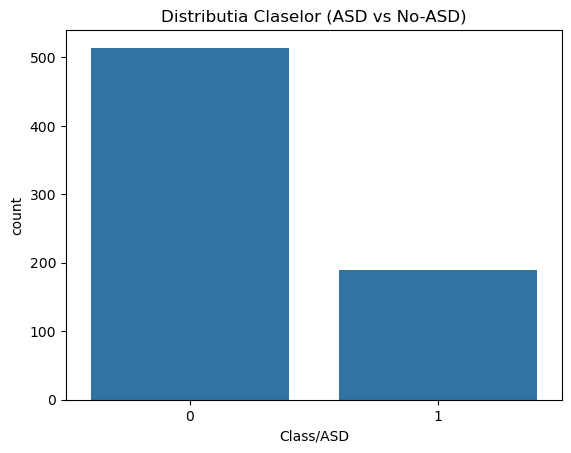

In [128]:
print(data['Class/ASD'].value_counts())
sns.countplot(x='Class/ASD', data=data)
plt.title('Distributia Claselor (ASD vs No-ASD)')
plt.show()

Am pastrat 85 coloane pentru antrenarea modelului.
Class/ASD
0    422
1    422
Name: count, dtype: int64


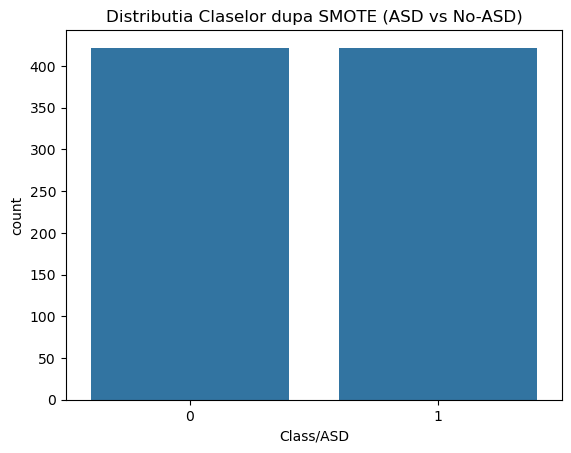

In [137]:
y = data['Class/ASD']
X = data.drop(columns=['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 
    'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 
    'result', 'Class/ASD'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


data['age'] = pd.to_numeric(data['age'], errors='coerce')
coloane_de_normalizat = ['age']
scaler = MinMaxScaler()
X_train[coloane_de_normalizat] = scaler.fit_transform(X_train[coloane_de_normalizat])
X_test[coloane_de_normalizat] = scaler.transform(X_test[coloane_de_normalizat])


smote = SMOTE(random_state=42)
X_train_balance, y_train_balance = smote.fit_resample(X_train, y_train)

print(f"Am pastrat {len(X.columns)} coloane pentru antrenarea modelului.")


print(y_train_balance.value_counts())
sns.countplot(x=y_train_balance)
plt.title('Distributia Claselor dupa SMOTE (ASD vs No-ASD)')
plt.show()

Primul model ales de noi este Logistic Regression. Acest model calculeaza pe baza valorilor de intrare si a functiei sigmoid, o probabilitate. In functie de aceasta probabilitate stabileste daca pacientul este unul bolnav sau sanatos. 
Modelul obtine o acuratete de aproape 76%, ceea ce indica o performanta moderata.

Analizand raportul de clasificare, putem observa ca modelul se descurca mai bine sa identifice pacientii sanatosi, avand precision 82% si recall 80%. Din pacate, cand vine vorba de pacientii bolnavi, valorile sunt mult mai mici: precision 65% si recall 67%, ceea ce indica dificultati in identificarea pacientilor bolnavi, ceea ce din punct de vedere medical, unde este important sa diagnosticam un pacient bolnav, este destul de rau.

Raport de clasificare pentru Logistic Regression:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        92
           1       0.65      0.67      0.66        49

    accuracy                           0.76       141
   macro avg       0.73      0.74      0.74       141
weighted avg       0.76      0.76      0.76       141

Acuratete Logistic Regression: 75.89%


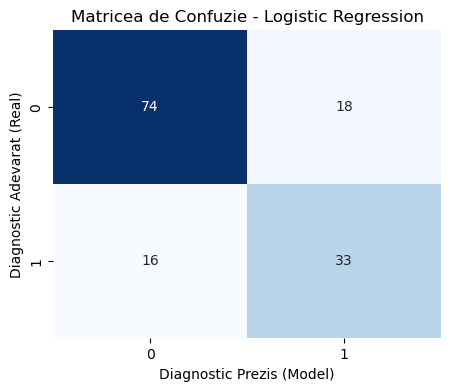

In [143]:
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_balance, y_train_balance)
y_pred_lr = model_lr.predict(X_test)
print("Raport de clasificare pentru Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

#Cate predictii sunt corecte din totalul de predictii
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Acuratete Logistic Regression: {acc_lr * 100:.2f}%")


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.ylabel('Diagnostic Adevarat (Real)')
    plt.xlabel('Diagnostic Prezis (Model)')
    plt.show()

plot_confusion_matrix(y_test, y_pred_lr, "Matricea de Confuzie - Logistic Regression")


![alt text](image-1.png)

Urmatorul model ales de noi este Decision Tree. Acest model verifica fiecare variabila si incearca sa faca o clasificare in functie de valoarea aceasteia cu scopul de a scadea entropia. 
Entropia este gradul de incertitudine a datelor. In momentul in care reusim sa clasificam o valoare direct, spunem ca entropia este 0, iar in momentul in care valorile sunt amestecate, spunem ca entropia este crescuta. Modelul incearca sa ajunga la noduri finale cat mai pure, noduri in care toate valorile apartin de o singura clasa.
Acuratetea este aproximativ aceeasi cu cea a modelului anterior 73%, insa daca ne uitam la precision si recall, valorile sunt mai mici, ceea ce face modelul si mai slab decat modelul anterior.

In [144]:
p=0.5
entropy = -p * log2(p) - (1-p) * log2(1-p)
entropy

1.0

Raport de clasificare pentru Decision Tree:
              precision    recall  f1-score   support

           0       0.76      0.86      0.81        92
           1       0.65      0.49      0.56        49

    accuracy                           0.73       141
   macro avg       0.70      0.67      0.68       141
weighted avg       0.72      0.73      0.72       141

Acuratete Decision Tree: 73.05%


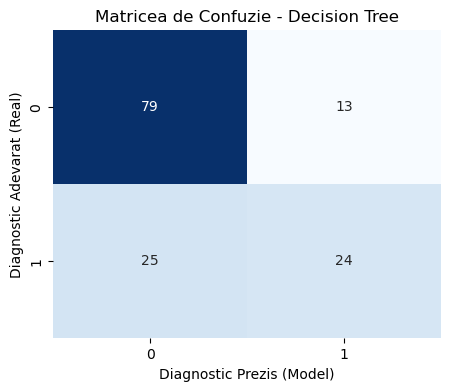

In [152]:
model_dt = DecisionTreeClassifier(criterion="entropy")
model_dt.fit(X_train_balance, y_train_balance)
y_pred_dt = model_dt.predict(X_test)
print("Raport de clasificare pentru Decision Tree:")
print(classification_report(y_test, y_pred_dt))

#Cate predictii sunt corecte din totalul de predictii
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Acuratete Decision Tree: {acc_dt * 100:.2f}%")

plot_confusion_matrix(y_test, y_pred_dt, "Matricea de Confuzie - Decision Tree")


Cel de al treilea model ales este Random Forest, care combina mai multi Decision Trees pentru a ajunge la o predictie finala mai precisa. Fiecare arbore este antrenat pe un subset diferit de date, iar rezultatul este obtinut prin votul majoritar al acestora. 
Acuratetea este mai buna decat la Decision trees datorita capacitatii de generalizare mai buna, iar precision si recall sunt de aproape 90% ceea ce sugereaza ca modelul este mult mai bun la clasificarea pacientilor sanatosi. Chiar daca valoarea preciziei si a recall-ului este mai buna decat pentru modelele anterioare, valorile sunt prea mici pentru un context medical, unde diagnosticarea bolii este esentiala.

Raport de clasificare pentru Random Forest:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85        92
           1       0.75      0.61      0.67        49

    accuracy                           0.79       141
   macro avg       0.78      0.75      0.76       141
weighted avg       0.79      0.79      0.79       141

Acuratete Random Forest: 79.43%


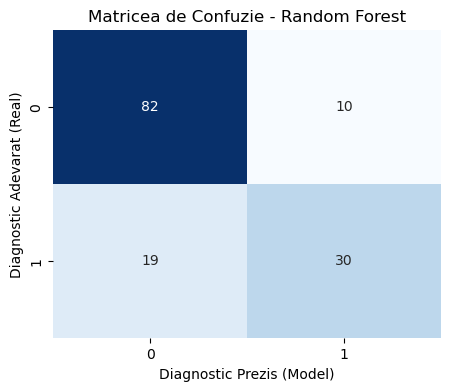

In [154]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_balance, y_train_balance)
y_pred_rf = model_rf.predict(X_test)
print("Raport de clasificare pentru Random Forest:")
print(classification_report(y_test, y_pred_rf))

#Cate predictii sunt corecte din totalul de predictii
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Acuratete Random Forest: {acc_rf * 100:.2f}%")

plot_confusion_matrix(y_test, y_pred_rf, "Matricea de Confuzie - Random Forest")


Un alt algoritm utilizat pentru clasificarea datelor este K-Nearest Neighbors (KNN). Am optat pentru acest model datorita flexibilitatii sale in ajustarea parametriilor de intrare care ne influenteaza performanta sistemului. In urma mai multor teste, am determinat ca valoarea optima pentru parametrul n_neighbors este 17, alte valori ducand la o scadere considerabila a acuratetii. De asemenea, aceasta configuratie performeaza optim cu metrica de distanta euclidiana; utilizarea altor metrici altereaza rezultatele obtinute.

In [192]:
knn = KNeighborsClassifier(n_neighbors=17, weights='distance', metric='euclidean')
knn.fit(X_train_balance, y_train_balance)
y_pred_knn = knn.predict(X_test)

print("KNN - Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['0', '1']))
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"Acuratete KNN: {acc_knn * 100:.2f}%")

KNN - Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.84        92
           1       0.71      0.69      0.70        49

    accuracy                           0.79       141
   macro avg       0.77      0.77      0.77       141
weighted avg       0.79      0.79      0.79       141

Acuratete KNN: 79.43%


Mai jos am extras importanta variabilelor pentru a vedea care variabile contribuie cel mai mult in predictia rezultatelor. Am luat scorul de importanta si am creat un tabel pe care pe urma l-am sortat descrescator si am selectat primele 10 variabile.
Se poate observa ca asa cum a prezis heatmap-ul, variabila pdd_autism are o importanta destul de ridicata in diagnosticarea pacientilor.

C:\Users\trifu\AppData\Local\Temp\ipykernel_8904\2780290065.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importante, x='Importance', y='Feature', palette='magma')


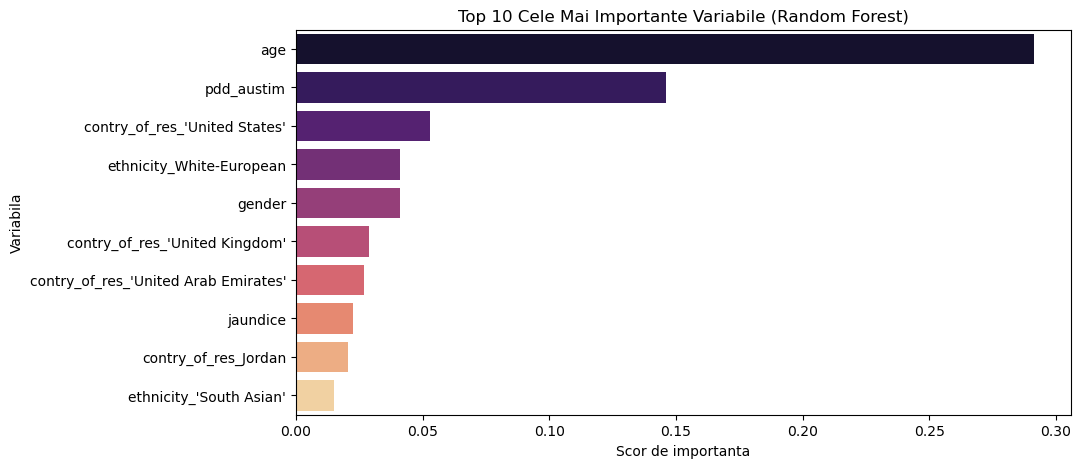

In [155]:
# Extragem importanta coloanelor din Random Forest
importante = model_rf.feature_importances_
coloane = X_train_balance.columns

# Cream un tabel si luam doar top 10
df_importante = pd.DataFrame({'Feature': coloane, 'Importance': importante})
df_importante = df_importante.sort_values(by='Importance', ascending=False).head(10)

# Desenam graficul
plt.figure(figsize=(10, 5))
sns.barplot(data=df_importante, x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Cele Mai Importante Variabile (Random Forest)')
plt.xlabel('Scor de importanta')
plt.ylabel('Variabila')
plt.show()

Un prim model complex ales este XGBoost, care combina mai multi arbori de decizie care incearca sa corecteze arborele anterior pentru a obtine o predictie cat mai precisa. Acuratetea modelului este mai buna decat cele procentele obtinute anterior. Acesta reuseste sa se descurce mai bine la detectarea pacienilor bolnavi avand o precizie aproape egala ca la detectia celor sanatosi 82%, dar totodata are un recall putin mai scazut de 67%. Deci XGBoost este un model mai complex care poate analiza mult mai eficient setul nostru de date dezechilibrat avand rezuultate mult mai bune fata de celalalte modele.

Raport de clasificare pentru XGBoost:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88        92
           1       0.82      0.67      0.74        49

    accuracy                           0.84       141
   macro avg       0.83      0.80      0.81       141
weighted avg       0.84      0.84      0.83       141

Acuratete XGBoost: 83.69%


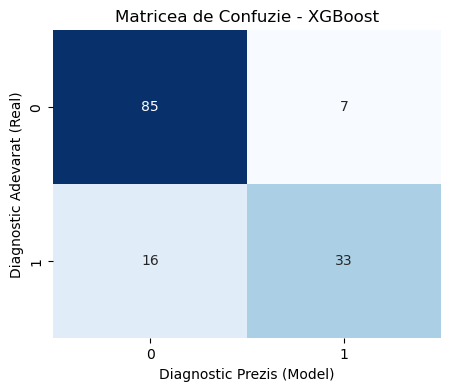

In [158]:
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_balance, y_train_balance)
y_pred_xgb = xgb_model.predict(X_test)
print("Raport de clasificare pentru XGBoost:")
print(classification_report(y_test, y_pred_xgb))

acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Acuratete XGBoost: {acc_xgb * 100:.2f}%")

plot_confusion_matrix(y_test, y_pred_xgb, "Matricea de Confuzie - XGBoost")

Un alt algoritm pentru etapa de clasificare este algoritmul LightGBM, antrenat pe un set de date echilibrat. Modelul a obtinut o acuratete generala de 78.72%, avand o performanta notabila in identificarea clasei 0, cu o precizie de 82% si un recall de 87%. Cu toate acestea, performanta scade in cazul clasei 1, unde recall-ul de doar 63% indica dificultati in identificarea corecta a tuturor instantelor pozitive.

Raport de clasificare pentru LightGBM:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84        92
           1       0.72      0.63      0.67        49

    accuracy                           0.79       141
   macro avg       0.77      0.75      0.76       141
weighted avg       0.78      0.79      0.78       141

Acuratete LightGBM: 78.72%


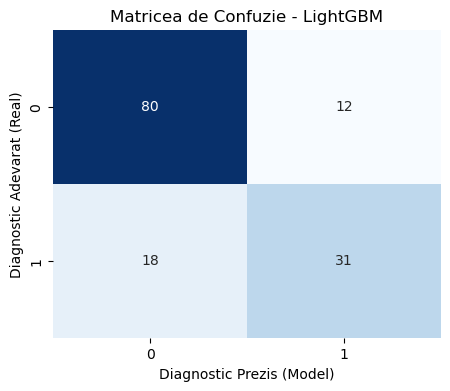

In [194]:
lgb_model = LGBMClassifier(random_state=42, verbose=-1)
lgb_model.fit(X_train_balance, y_train_balance)
y_pred_lgb = lgb_model.predict(X_test)

print("Raport de clasificare pentru LightGBM:")
print(classification_report(y_test, y_pred_lgb))

acc_lgb = accuracy_score(y_test, y_pred_lgb)
print(f"Acuratete LightGBM: {acc_lgb * 100:.2f}%")

plot_confusion_matrix(y_test, y_pred_lgb, "Matricea de Confuzie - LightGBM")

Ultimul model testat de noi este Naive Bayes, care desi este considerat mai eficient in multe cazuri, acesta presupune ca variabilele cu care lucreaza sunt independente, ceea ce nu este 100% valid pentru datele noastre. Astfel, rezultatele modelului sunt slabe, cu o acuratete 40%. Totusi valoarea recall pentru pacientii bolnavi este de 98%, cea mai mare valoare obtinuta de pana acum, insa nu putem sa nu luam in considerare celelalte metrici foarte slabe care trag acest model in jos.

Naive Bayes - Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.10      0.18        92
           1       0.37      0.98      0.53        49

    accuracy                           0.40       141
   macro avg       0.63      0.54      0.35       141
weighted avg       0.71      0.40      0.30       141

Acuratete Naive Bayes: 40.43%


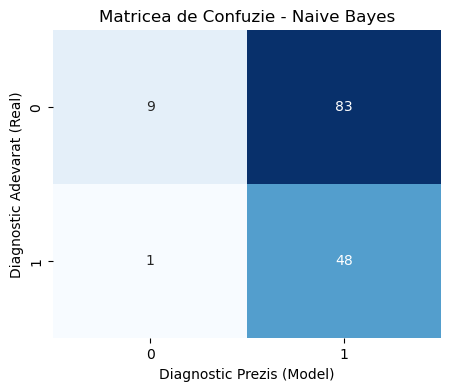

In [188]:
nb = GaussianNB()
nb.fit(X_train_balance, y_train_balance)
y_pred_nb = nb.predict(X_test)
print("Naive Bayes - Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['0', '1']))

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Acuratete Naive Bayes: {acc_nb * 100:.2f}%")

plot_confusion_matrix(y_test, y_pred_nb, "Matricea de Confuzie - Naive Bayes")

CONCLUZII:

Din analiza modelelor, se poate observa ca XGBoost este cel mai performant, avand o acuratete de aproape 84%. Datorita mecanismului sau care combina mai multi arbori de decizie care incearca sa corecteze arborele anterior pentru a obtine o predictie cat mai precisa, XGBoost reuseste sa se evidentieze si sa generalizeze mai bine pe setul de date. 

Logistic Regresion si RandomForestClassifier au performante apropiate insa nu reusesc sa surprinda relatii mai complexe, iar DecisionTreeClassifier chiar daca e un model mai putin complex, nu performeaza la fel de bine probabil din cauza corelatiilor destul de slabe intre variabile si variabila tinta.

LightGBM, desi este un model asemanator cu XGBoost si destul de puternic, poate da rezultate mai slabe in cazul nostru deoarece trebuie reglat mai atent ca sa functioneze bine. Daca nu este optimizat corect, nu reuseste sa invete la fel de bine din date. De asemenea, K-Nearest Neighbour nu performeaza la fel de bine ca XGBoost deoarece se bazeaza doar pe cat de apropiate sunt valorile intre ele si nu reuseste sa prinda relatii mai complicate dintre variabile, chiar daca datele au fost prelucrate si echilibrate.

Naive Bayes este cel mai slab model, deoarece presupune ca toate variabilele sunt independente intre ele, ceea ce nu este realist pentru acest set de date unde exista legaturi intre caracteristici. Din aceasta cauza, modelul nu reuseste sa invete corect relatiile din date si ofera rezultate mult mai slabe comparativ cu celelalte modele.

Cu mai mult timp si resurse, am incerca sa facem rost de mai multe exemple pentru pacientii in varsta, astfel reducand impactul outlierilor si pentru a avea o distributie de varste mai echilibrata. De asemenea, am include date mai variate mai ales din punct de vedere al etniilor si al tarilor natale si probabil ca am adauga informatii suplimentare legate de istoricul medical cum ar fii afectiuni asociate. Aceste masuri ar ajuta modelele sa invete relatii mai complexe si sa detecteze mai corect pacientii bolnavi, crescand relevanta intr-un context medical.